Hannath T

<h2>BIKE RENTAL PROJECT</h2>

<h5>Goal</h5>

The goal is to create a model that can predict how many bikes will be rented on a given day.

<h5>Abstract</h5>

Bike rental systems generate large amounts of data related to weather conditions, seasonal patterns, and user behavior. Analyzing this data can help understand urban mobility and predict future bike rental demand.

The results of this project demonstrate that environmental and seasonal features play a significant role in predicting bike rental demand. This project highlights how data-driven approaches can support demand forecasting and decision-making in bike-rental systems, contributing to efficient urban transportation planning.Also Expecting to detect important events in the city by analysing the data.

Bike sharing systems are a new version of traditional bike rentals where the whole process from membership, rental and return back has been automated. Through these systems, users are easily able to rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues. Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns the bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of the important events in the city could be detected via monitoring these data.

<h5>Tasks:</h5>

Task 1:- Prepare a complete data analysis report on the given data.

Task 2:- Create a Predictive model that could predict daily bike rental count based on the environmental and seasonal settings.

Task 3:- Create a report stating the performance of multiple models on this data and suggest the best model for production.

Task 4:- Create a report which should include challenges you faced on data and what technique was used with proper reasoning.

<h5>Attribute Information:</h5>

Both the files hour.csv and day.csv have the following fields, except hr which is not available in day.csv
1. instant: record index
2. dteday : date (date of each Bike rental record)
3. season : season (1:winter, 2:spring, 3:summer, 4:fall)-> seasons of recorded bike rental represent in 1 to 4
4. yr : year (0: 2011, 1: 2012)
5. mnth : month ( 1 to 12)-> jan to dec represented by 1 to 12
6. hr : hour (0 to 23)
7. holiday : weather day is holiday or not
8. weekday : day of the week
9. workingday : if neither weekend nor holiday, it is 1; otherwise 0.
10. weathersit :
 1: Clear, Few clouds, Partly cloudy, Partly cloudy
 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
 4: Heavy Rain + Ice Pellets + Thunderstorm + Mist, Snow + Fog
11. temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
12. atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
13. hum: Normalized humidity. The values are divided to 100 (max)
14. windspeed: Normalized wind speed. The values are divided to 67 (max)
15. casual: count of casual users
16. registered: count of registered users
17. cnt: count of total rental bikes including both casual and registered

- cnt is the target variable
- temp: actual temperature 
- atemp: temperature felt by people
- normalising: converting features to same range (better model learning)

<h5>Project type : Regression</h5>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dy_df=pd.read_csv("day.csv")

In [3]:
hr_df=pd.read_csv("hour.csv")

<h4>basic checks</h4>

In [4]:
dy_df.equals(hr_df)

False

In [5]:
dy_df.shape

(731, 16)

In [6]:
hr_df.shape

(17379, 17)

In [7]:
dy_df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [8]:
hr_df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Given that both the files hour.csv and day.csv have the same fields, except hr which is not available in day.csv

In [9]:
hr_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [10]:
dy_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [11]:
hr_df.head(20)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [12]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [13]:
dy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [14]:
hr_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [15]:
dy_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


data cleaning

In [16]:
hr_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [17]:
dy_df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [18]:
hr_df.duplicated().sum()

np.int64(0)

In [19]:
dy_df.duplicated().sum()

np.int64(0)

- hour dataset have 17379 rows and 17 columns
- day dataset have 731 rows and 16 columns
- no null value and duplicates present
- dataset looks numerical but has both numerical and categorical values(eg : season (1,2,3,4))

<h4>Exploratory Data Analysuis</h4>

In [20]:
hr_df['holiday'].value_counts()

holiday
0    16879
1      500
Name: count, dtype: int64

<Axes: xlabel='holiday', ylabel='count'>

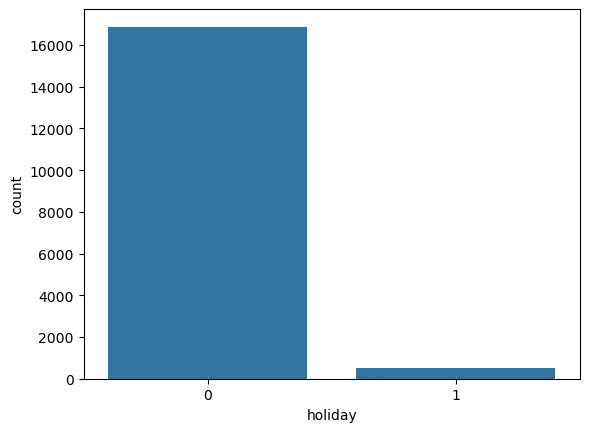

In [21]:
sns.countplot(x='holiday',data=hr_df)

In [22]:
hr_df.groupby('holiday')['cnt'].mean()

holiday
0    190.42858
1    156.87000
Name: cnt, dtype: float64

- **mean value is higher and more records on dataset is on non holidays , means more rental recorded on non holidays**

In [23]:
hr_df['workingday'].value_counts()

workingday
1    11865
0     5514
Name: count, dtype: int64

<Axes: xlabel='workingday', ylabel='count'>

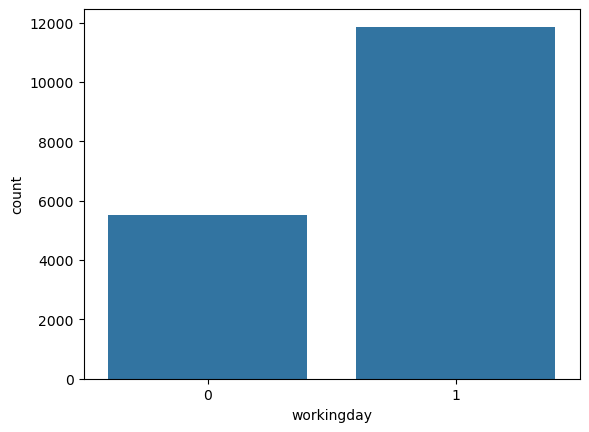

In [24]:
sns.countplot(x='workingday',data=hr_df)

- **more data is on workinday , more bike rental happened on workingdays**

In [25]:
hr_df.groupby('workingday')['cnt'].mean()#group by workingdays and calculate the mean of cnt(target)

workingday
0    181.405332
1    193.207754
Name: cnt, dtype: float64

- **Working days show higher average rentals, suggesting significant commuter usage.**

In [26]:
hr_df.groupby('weekday')['cnt'].mean()

weekday
0    177.468825
1    183.744655
2    191.238891
3    191.130505
4    196.436665
5    196.135907
6    190.209793
Name: cnt, dtype: float64

- **0->sunday(holiday) showed drop in rental**

In [27]:
hr_df.groupby('yr')['cnt'].mean()

yr
0    143.794448
1    234.666361
Name: cnt, dtype: float64

- **2012 year peaked in average bike rental ,shows the bike-sharing system became more popular over time(growth).**

In [28]:
hr_df.groupby('mnth')['cnt'].mean()

mnth
1      94.424773
2     112.865026
3     155.410726
4     187.260960
5     222.907258
6     240.515278
7     231.819892
8     238.097627
9     240.773138
10    222.158511
11    177.335421
12    142.303439
Name: cnt, dtype: float64

- **june and september with highest rental(could be good weather period**

In [29]:
hr_df.groupby('weathersit')['cnt'].mean()

weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: cnt, dtype: float64

- **Clear weather conditions result in the highest rental counts, while adverse weather significantly reduces demand.**

<Axes: xlabel='cnt', ylabel='Count'>

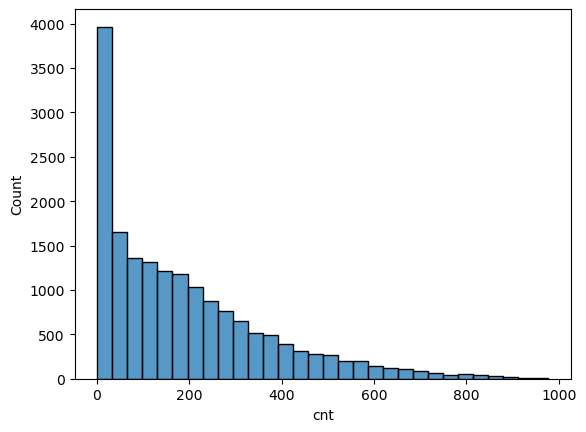

In [30]:
sns.histplot(hr_df['cnt'],bins=30)

- **few high rental records**
- **most are less to moderate rental counts**

<Axes: ylabel='Count'>

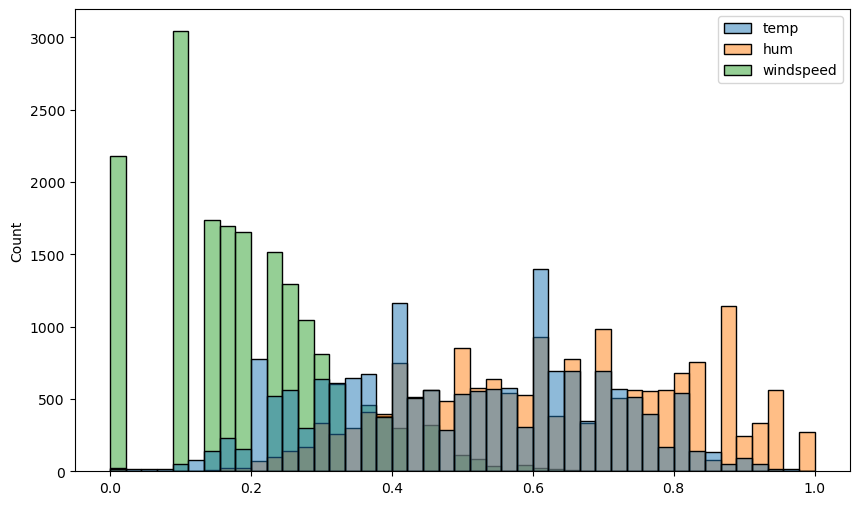

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(hr_df[['temp','hum','windspeed']])

array([[<Axes: title={'center': 'temp'}>,
        <Axes: title={'center': 'hum'}>],
       [<Axes: title={'center': 'windspeed'}>,
        <Axes: title={'center': 'atemp'}>]], dtype=object)

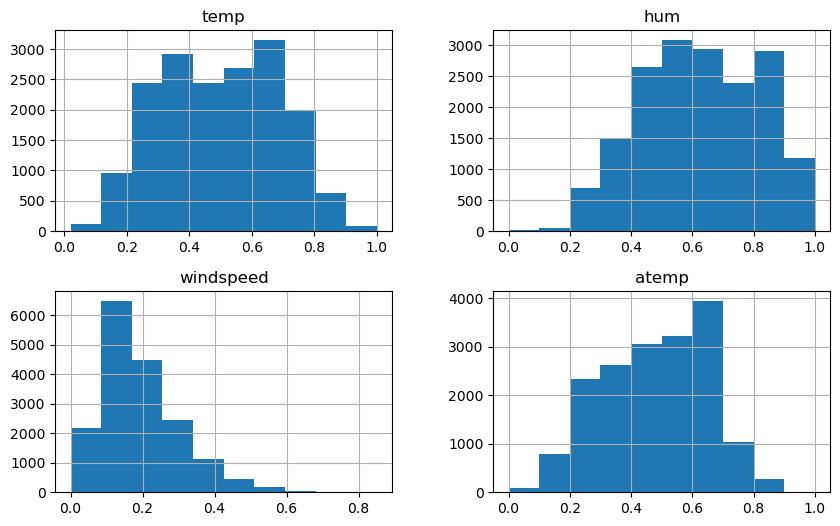

In [32]:
hr_df[['temp','hum','windspeed','atemp']].hist(figsize=(10,6))

- **temp and atemp shows similar distribution patterns, indicating a strong relationship between the two variables(multicollinearity**
- **more datas are among moderate temperture ,suggesting that most recorded rentals occur under comfortable weather conditions.(not too cold or hot)**
- **Humidity is widely distributed ,but extreame values (too low and too high) is affecting badly for the rendal record**
- **Extreame wind is very less in dataset ,suggesting that rental can reduce in extreame windy conditions.**

<Axes: xlabel='temp', ylabel='cnt'>

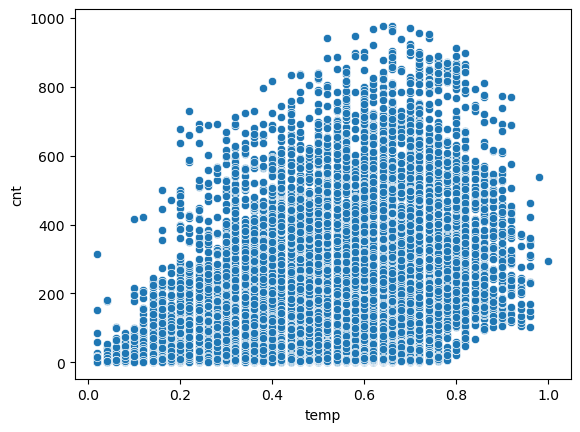

In [33]:
sns.scatterplot(x='temp',y='cnt',data=hr_df)

- **Bike rentals increase with temperature up to a comfortable range, after which demand stabilizes.**

<Axes: xlabel='temp', ylabel='cnt'>

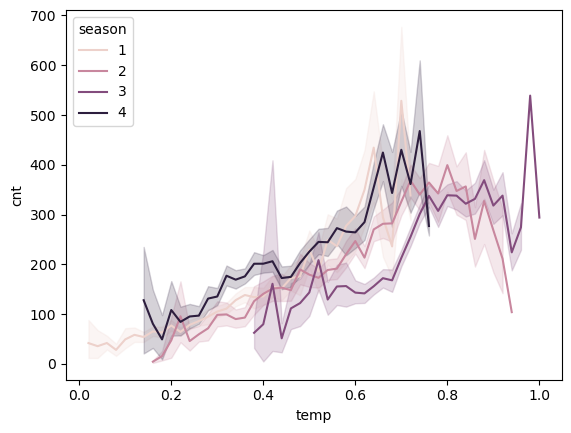

In [34]:
sns.lineplot(x='temp', y='cnt', hue='season', data=hr_df)

season (1:winter, 2:spring, 3:summer, 4:fall)
- **Bike rental increases as temperature increases upto a moderate level for all seasons**
- **moderate temperature has highest demand**
- **winter and fall showing peak values during moderate temperature**

<Axes: xlabel='hum', ylabel='cnt'>

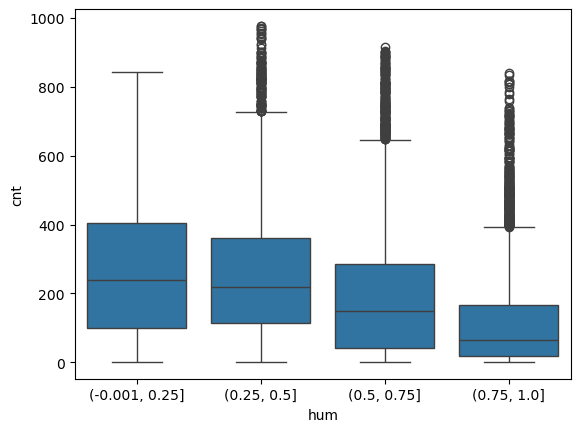

In [35]:
sns.boxplot(x=pd.cut(hr_df['hum'], bins=4), y='cnt', data=hr_df)#cut used to convert the continuos values into categories

- **High humidity levels are associated with reduced bike rentals, likely due to discomfort**

<Axes: xlabel='windspeed', ylabel='cnt'>

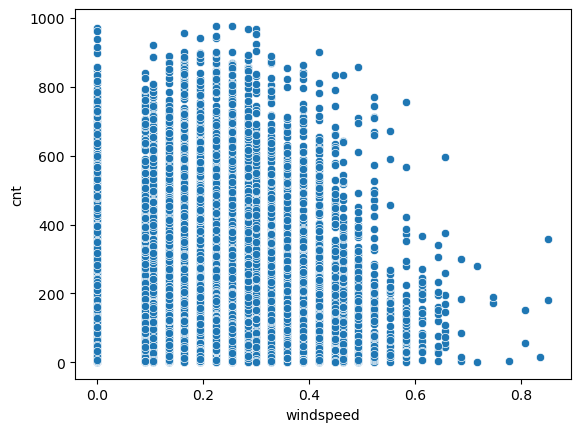

In [36]:
sns.scatterplot(x='windspeed', y='cnt', data=hr_df)

- **Higher wind speeds generally correspond to lower bike rental counts, indicating wind has a bad influence to renting bike**

<Axes: xlabel='season', ylabel='cnt'>

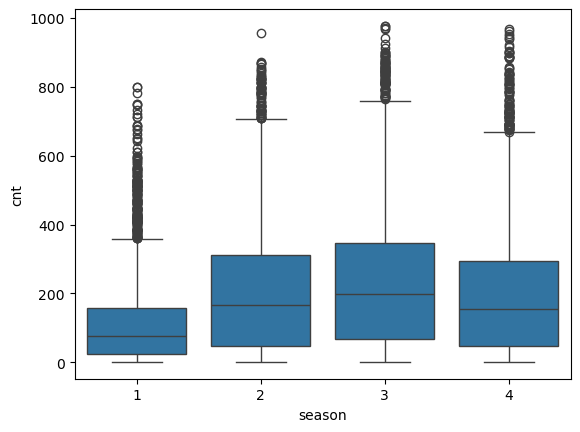

In [37]:
sns.boxplot(x='season', y='cnt', data=hr_df)

- **Winter show lower median bike rentals, suggesting unfavorable weather conditions decreases bike usage and visa versa**

<Axes: ylabel='cnt'>

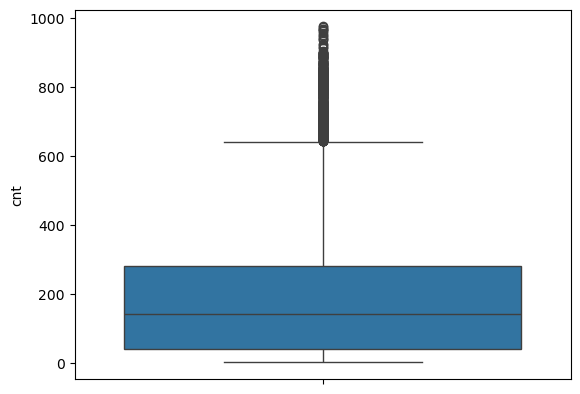

In [38]:
sns.boxplot(y=hr_df['cnt'])

- **High rental counts(outliers) can also be festivals, peak commute, good weather or importand event**

<Axes: >

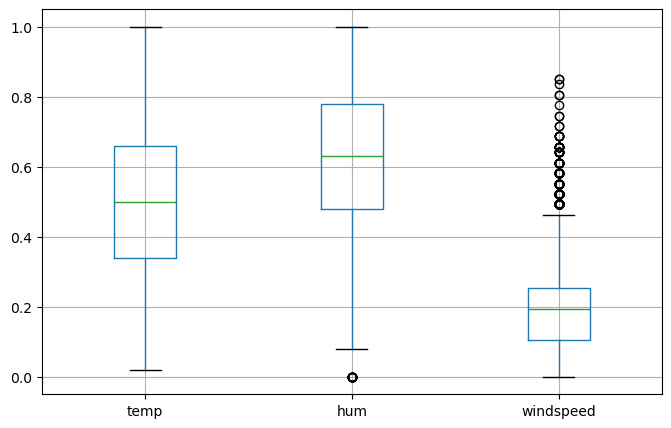

In [39]:
hr_df[['temp','hum','windspeed']].boxplot(figsize=(8,5))

- **No unrealistic values found (outliers),acceptable outliers**

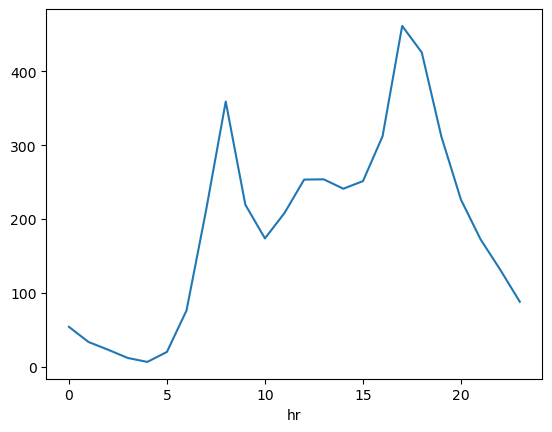

In [40]:
hr_df.groupby('hr')['cnt'].mean().plot(kind='line')
plt.show()

- **Rental peaking on morning and evening hours shows commuter usage**
- **this could means people are relieing on bike to office ,college etc**

<Axes: >

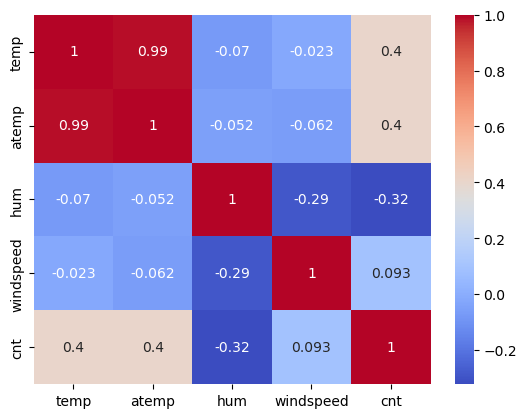

In [41]:
corr = hr_df[['temp','atemp','hum','windspeed','cnt']].corr()
sns.heatmap(corr, annot=True,cmap='coolwarm')

- **temp and atemp are highly correlated(they carry the same information)**
- **humidity has negative correlation (higher hum lower rental)**
- **windspeed also has weak correlation (slight decrease in rental with increase in windspeed**

<h4>Some imporatant insights</h4>

- Compute hour(morning 8-10 and 4-6) has most bike demand
- Temperature and temperature felt by people are influencing the rent
- Bike demand is increasing over time
- bike rental increases on favorable weather condition
- Higher demand on bike during workingdays

<h4>Task 1:- Prepare a complete data analysis report on the given data</h4>

<h4>Feature Engineering</h4>

- dropping unnecessary columns
  * instant -> was counting number of each data
  * dtedat -> date dont influence the rent but the type and nature of that day does
  * casual and registered -> is subset of cnt(no bigger insights from these)

In [42]:
hr_df=hr_df.drop(['instant','dteday','casual','registered'],axis=1)

In [43]:
hr_df.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


<h5>Feature Selection</h5>

- dropping one from correlated features for better model performance for lenear model
- dropping temp and keeping atemp

In [44]:
hr1_df=hr_df.drop(columns=['temp'])

In [45]:
hr1_df

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,atemp,hum,windspeed,cnt
0,1,0,1,0,0,6,0,1,0.2879,0.81,0.0000,16
1,1,0,1,1,0,6,0,1,0.2727,0.80,0.0000,40
2,1,0,1,2,0,6,0,1,0.2727,0.80,0.0000,32
3,1,0,1,3,0,6,0,1,0.2879,0.75,0.0000,13
4,1,0,1,4,0,6,0,1,0.2879,0.75,0.0000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,1,12,19,0,1,1,2,0.2576,0.60,0.1642,119
17375,1,1,12,20,0,1,1,2,0.2576,0.60,0.1642,89
17376,1,1,12,21,0,1,1,1,0.2576,0.60,0.1642,90
17377,1,1,12,22,0,1,1,1,0.2727,0.56,0.1343,61


In [46]:
#separating target column
x=hr1_df.drop('cnt',axis=1)
y=hr1_df['cnt']

In [47]:
x

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.2879,0.81,0.0000
1,1,0,1,1,0,6,0,1,0.2727,0.80,0.0000
2,1,0,1,2,0,6,0,1,0.2727,0.80,0.0000
3,1,0,1,3,0,6,0,1,0.2879,0.75,0.0000
4,1,0,1,4,0,6,0,1,0.2879,0.75,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
17374,1,1,12,19,0,1,1,2,0.2576,0.60,0.1642
17375,1,1,12,20,0,1,1,2,0.2576,0.60,0.1642
17376,1,1,12,21,0,1,1,1,0.2576,0.60,0.1642
17377,1,1,12,22,0,1,1,1,0.2727,0.56,0.1343


In [48]:
y

0         16
1         40
2         32
3         13
4          1
        ... 
17374    119
17375     89
17376     90
17377     61
17378     49
Name: cnt, Length: 17379, dtype: int64

<h5>train and test split</h5>

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,
    random_state=42)

In [50]:
x_train.shape

(13903, 11)

In [51]:
x_test.shape

(3476, 11)

In [52]:
y_train

335       72
7035     518
8051       3
2133     172
8485       1
        ... 
11284    359
11964    812
5390     189
860      100
15795    779
Name: cnt, Length: 13903, dtype: int64

In [53]:
y_test

12830    425
8688      88
7091       4
12230    526
431       13
        ... 
6759      17
13989     85
173       98
16192    266
8211     267
Name: cnt, Length: 3476, dtype: int64

<h5>selecting categorical and numerical</h5>

In [54]:
categorical_cols = [
    'season', 'weathersit',
    'holiday', 'workingday',
    'yr', 'mnth', 'weekday', 'hr'
]
numerical_cols = ['atemp', 'hum', 'windspeed']

<h4>One-hot encoding and Scaling</h4>

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [56]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

<h4>Trying differnt model</h4>

<h4>Linear Regression</h4>

In [57]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [58]:
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])
model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['atemp', 'hum',
                                                   'windspeed']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['season', 'weathersit',
                                                   'holiday', 'workingday',
                                                   'yr', 'mnth', 'weekday',
                                                   'hr'])])),
                ('regressor', LinearRegression())])

In [59]:
y_pred = model.predict(x_test)

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr=mean_absolute_error(y_test, y_pred)
mse_lr=mean_squared_error(y_test, y_pred)
rmse_lr=np.sqrt(mse_lr)
r2_lr=r2_score(y_test, y_pred)

print("MAE:",mae_lr)
print("RMSE:",rmse_lr)
print("R²:", r2_lr)

MAE: 74.17790367018267
RMSE: 100.50227592358401
R²: 0.6810176454524322


- showing low performance

<h4>KNN</h4>

In [61]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', KNeighborsRegressor(
        n_neighbors=10,
        weights='distance',
        metric='minkowski'
    ))
])
knn_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['atemp', 'hum',
                                                   'windspeed']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['season', 'weathersit',
                                                   'holiday', 'workingday',
                                                   'yr', 'mnth', 'weekday',
                                                   'hr'])])),
                ('regressor',
                 KNeighborsRegressor(n_neighbors=10, weights='distance'))])

In [62]:
y_pred_knn = knn_model.predict(x_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Results")
print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R²:", r2_knn)

KNN Results
MAE: 70.14626234463292
RMSE: 100.92755774357124
R²: 0.6783123451690574


- Bad performance by KNN

<h4>Random Forest</h4>

In [63]:
from sklearn.ensemble import RandomForestRegressor
rf_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])
rf_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['atemp', 'hum',
                                                   'windspeed']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['season', 'weathersit',
                                                   'holiday', 'workingday',
                                                   'yr', 'mnth', 'weekday',
                                                   'hr'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [64]:
y_pred_rf = rf_model.predict(x_test)

In [65]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)


Random Forest Results
MAE: 32.638179677653575
RMSE: 51.31186388297136
R²: 0.9168522604311384


<h5>cross validation</h5>

In [66]:
#cross valiiii
cv_rf = cross_val_score(
    rf_model,
    x_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("RF CV R² mean:", cv_rf.mean())

NameError: name 'cross_val_score' is not defined

- good performance but slow

<h4>Gradient Boosting</h4>

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])
gb_model.fit(x_train, y_train)

In [ ]:
y_pred_gb = gb_model.predict(x_test)

In [ ]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

<h5>Cross validation</h5>

In [ ]:
# Cross-validation
cv_gb = cross_val_score(
    gb_model,
    x_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("GB CV R² mean:", cv_gb.mean())

- **showing good performance**
- **one among the best**

<h4>XGBoost</h4>

In [ ]:
from xgboost import XGBRegressor
xgb_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    ))
])
xgb_model.fit(x_train, y_train)

In [ ]:
y_pred_xgb = xgb_model.predict(x_test)

In [ ]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²:", r2_xgb)

<h5>Cross validation</h5>

In [ ]:
cv_xgb = cross_val_score(
    xgb_model,
    x_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("XGB CV R² mean:", cv_xgb.mean())

- **very Good performance by XGBoost**
- **The best R2 and RMSE**

<h4>SVM</h4>

In [ ]:
from sklearn.svm import SVR
svr_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', SVR(
        kernel='rbf',
        C=100,
        gamma='scale',
        epsilon=0.1
    ))
])
svr_model.fit(x_train, y_train)

In [ ]:
y_pred_svr = svr_model.predict(x_test)

In [ ]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Results")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R²:", r2_svr)

- comparitvely slow so not going with cross validation(can be slower)

<h4>Compairing Models</h4>

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting','XGBoost','SVR','KNN'],
    'R2': [r2_lr, r2_rf, r2_gb,r2_xgb,r2_svr,r2_knn],
    'MAE': [mae_lr, mae_rf, mae_gb,mae_xgb,mae_svr,mae_knn],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb,rmse_xgb,rmse_svr,rmse_knn]
})

results

**After Compairing SIX models**

- KNN and Linear Regression gave the worse performance
- KNN with RMSE value 100 
- Random Forest with good performance with but slow (trying tuning)
- Gradient Boosting showed bad RMSE value and bad performance
- SVR was slow
- XGBoost Outperformed all the models
- Highest R2 -> XGBoost
- Lowest MAE -> XGBoost,RAndom Forest and SVR
- Lowest RMSE -> XGBoost

**selected best model for hyperparameter tuning**

<h4>Hyperparameter tuning on random forest</h4>

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'regressor__n_estimators': [200, 400],
    'regressor__max_depth': [None, 20, 30],
    'regressor__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
rf_grid.fit(x_train, y_train)

In [ ]:
print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV R²:", rf_grid.best_score_)

In [ ]:
best_rf_model = rf_grid.best_estimator_

In [ ]:
y_pred_rf_tuned = best_rf_model.predict(x_test)

In [ ]:
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
print("Tuned XGBoost Results")
print("MAE:", mae_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("R²:", r2_rf_tuned)

<h4>Hyperparameter Tuning on xgb</h4>

In [ ]:
from sklearn.model_selection import GridSearchCV
xgb_param_grid = {
    'regressor__n_estimators': [200, 300],
    'regressor__max_depth': [4, 6],
    'regressor__learning_rate': [0.05, 0.1]
}

In [ ]:
xgb_grid = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1)
xgb_grid.fit(x_train, y_train)
print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB CV R²:", xgb_grid.best_score_)

In [ ]:
best_xgb_model = xgb_grid.best_estimator_

In [ ]:
y_pred_xgb_tuned = best_xgb_model.predict(x_test)

In [ ]:
mae_xgb_tuned = mean_absolute_error(y_test, y_pred_xgb_tuned)
rmse_xgb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))
r2_xgb_tuned = r2_score(y_test, y_pred_xgb_tuned)
print("Tuned XGBoost Results")
print("MAE:", mae_xgb_tuned)
print("RMSE:", rmse_xgb_tuned)
print("R²:", r2_xgb_tuned)

<h4>Hyperparameter Tuning on gradient boosting</h4>

In [ ]:
gb_param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 4]
}
gb_grid = GridSearchCV(
    gb_model,
    gb_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
gb_grid.fit(x_train, y_train)
print("Best GB Params:", gb_grid.best_params_)
print("Best GB CV R²:", gb_grid.best_score_)

In [ ]:
best_gb_model = gb_grid.best_estimator_

In [ ]:
y_pred_gb_tuned = best_gb_model.predict(x_test)

In [ ]:
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)
print("Tuned gradient boost Results")
print("MAE:", mae_gb_tuned)
print("RMSE:", rmse_gb_tuned)
print("R²:", r2_gb_tuned)

<h4>Compairing after tuning</h4>

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting','XGBoost'],
    'R2': [r2_rf_tuned, r2_gb_tuned,r2_xgb_tuned],
    'MAE': [mae_rf_tuned, mae_gb_tuned,mae_xgb_tuned],
    'RMSE': [rmse_rf_tuned, rmse_gb_tuned,rmse_xgb_tuned]
})
results

- **clearly XGBoost outperformed all other models**
  - highest R2 : 93.00
  - Lowest Mae : 30.53
  - Lowest RMSE : 47.06

<h4>Selected XGBoost as the final Model</h4>

<h4>Completed Task 3:- Create a report stating the performance of multiple models on this data and suggest the best model for production</h4>

<h4>Feature Importance</h4>

In [ ]:
preprocessor = best_xgb_model.named_steps['preprocessing']
xgb_regressor = best_xgb_model.named_steps['regressor']
feature_names = preprocessor.get_feature_names_out()
importances = xgb_regressor.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
feature_importance_df.head(10)

- Commute hour is on top -> most influencing 
  - cat__hr_17 ( 5 to 6 PM) and cat__hr_18 (6 to 7 PM ) -> showing evening demand
  - cat__hr_8 (8 to 9 AM) -> showing morning demand
- this shows that the hour feature is the most influencing feature

In [ ]:
#other than hour
feature_importance_df[~feature_importance_df['Feature'].str.contains('hr')].head(10)

- Working day ,year ,atemp is the most importannd feature after hour

<h4>Trying day dataset</h4>

In [ ]:
#seperating target
X_day = dy_df.drop('cnt', axis=1)
y_day = dy_df['cnt']

In [ ]:
#train test split
X_day_train, X_day_test, y_day_train, y_day_test = train_test_split(
    X_day, y_day, test_size=0.2, random_state=42
)

In [ ]:
#selecting categorical and numerical variable
categorical_cols_day = [
    'season', 'weathersit',
    'holiday', 'workingday',
    'yr', 'mnth', 'weekday'
]

numerical_cols_day = ['atemp', 'hum', 'windspeed']

In [ ]:
#preprocessing (one hot encoding and scaling)
preprocessor_day = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_day),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols_day)
    ]
)

In [ ]:
#model
xgb_day_model = Pipeline(steps=[
    ('preprocessing', preprocessor_day),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    ))
])

In [ ]:
xgb_day_model.fit(X_day_train, y_day_train)

In [ ]:
y_day_pred = xgb_day_model.predict(X_day_test)

In [ ]:
print("Day Dataset Results")
print("MAE:", mean_absolute_error(y_day_test, y_day_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_day_test, y_day_pred)))
print("R²:", r2_score(y_day_test, y_day_pred))

- showing good R2 value and performance

In [ ]:
#cross validation
cv_scores_day = cross_val_score(
    xgb_day_model,
    X_day_train,
    y_day_train,
    cv=5,
    scoring='r2'
)
print("Day Dataset CV R² Mean:", cv_scores_day.mean())

In [ ]:
#hyperparameter tuning
param_grid_day = {
'regressor__n_estimators': [200, 300],
    'regressor__max_depth': [4, 6],
    'regressor__learning_rate': [0.05, 0.1]
}
day_grid = GridSearchCV(
    xgb_day_model,
    param_grid_day,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
day_grid.fit(X_day_train, y_day_train)
print("Best Day Params:", day_grid.best_params_)
print("Best Day CV R²:", day_grid.best_score_)

In [ ]:
#feature seletion
best_day_model = day_grid.best_estimator_
preprocessor_day = best_day_model.named_steps['preprocessing']
xgb_day_regressor = best_day_model.named_steps['regressor']
feature_names_day = preprocessor_day.get_feature_names_out()
importances_day = xgb_day_regressor.feature_importances_
feature_importance_day_df = pd.DataFrame({
    'Feature': feature_names_day,
    'Importance': importances_day
}).sort_values(by='Importance', ascending=False)
feature_importance_day_df.head(10)

- Year ,season and atemp is most influencing feature in this dataset

<h4>Completed Task 2:- Create a Predictive model that could predict daily bike rental count based on the environmental and seasonal settings</h4>

<h4>Challenges Faced and Technique used</h4>

1. Type of Data:
    * Dataset looks like fully Numerical.
    * Presents of data that is categorical but looks numerical.
    * This can be a challenge on Preprocessing
* Technique used :
    * Careful reviewing of data
    * Better understanding of dataset before preprocessing
    * EDA
      
2. Multicollinearity :
    * temp and atemp are correlated
    * Negative effect models
    * Reduce interpretability
* Technique used :
    * Analysis using heatmap
    * feature selection

3. Categorical data :
    * Multiple categorical features
    * Models cannot work on categorical data
    * Challenges the machine
* Technique used :
    * One-hot encoding
    * converted categorical features to numericals
    * Reduced challenges on machine

4. Different Ranges of numerical data :
    * Numerical features had very different ranges
    * affects the model performance
* Technique Used :
    * Scailing Technique
    * Numerical features to same range
    * Fair comparison across model
    * prevent dominance of large ranged model
      
5. Risk of Overfitting :
    * fail to generalize to unseen data.
* Technique Used :
    * Cross validation
    * Evaluated Model stablity

<h4>Completed Task 4:- Create a report which should include challenges you faced on data and what technique was used with proper reasoning</h4>